In [84]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import math
import random

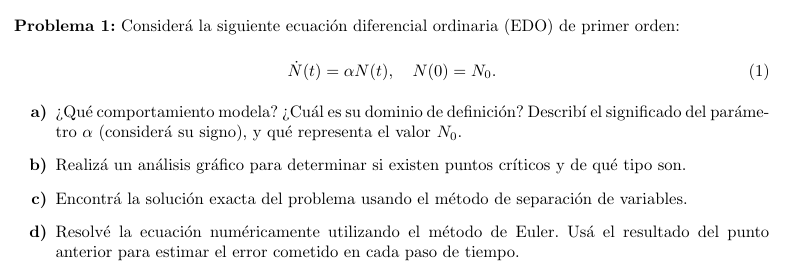

**a) ¿Qué comportamiento modela? ¿Cuál es su dominio de definición? Describí el significado del parámetro α (considerá su signo), y qué representa el valor N0.**

$\dot{N}(t) = \alpha N(t)$ ; $N(0) = N_{0}$

**Solución del problema**

$\frac{dN(t)}{dt} = \alpha N(t)$ <br>
$\frac{dN}{N} = \alpha$ <br>
$\int_{N_{0}}^{N} \frac{dN}{N} = \int_{t0}^{t} \alpha dt$ <br>
$ln(N)-ln(N_{0}) = \alpha t + C$ <br>
$\frac{N}{N_{0}} = e^{\alpha t + C}$ <br>
$N = N_{0}e^{\alpha t + C}$ <br>







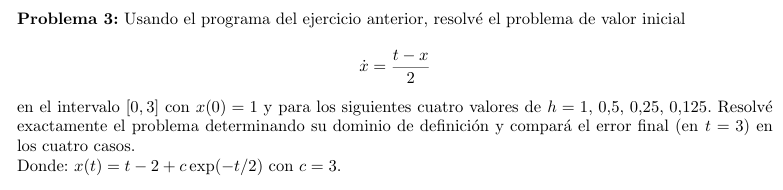

In [ ]:
# Import data
paths_list = []
data_path = 'tp3e3'

## Sort directions
path_names = sorted(next(os.walk(data_path))[-1])

# Print paths list
path_names
#pd.read_csv('tp3e3\output_h1.csv', header = None)

['output_h0125.csv', 'output_h025.csv', 'output_h05.csv', 'output_h1.csv']

In [71]:
# Create dicts to extract data
dict_x = {}
dict_t = {}

# Iterate with a for loop to extract data
for p in path_names:

    #p[7:-4]
    data = pd.read_csv(os.path.join(data_path, p), header = None)
    dict_x[p[7:-4]] = data.loc[:, 1].values
    dict_t[p[7:-4]] = data.loc[:, 0].values


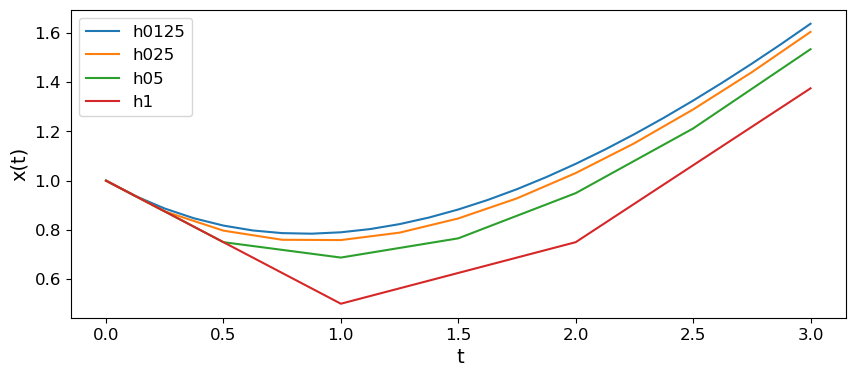

In [72]:
# Plot Euler method results 
h_steps = dict_x.keys()

fig, ax = plt.subplots(figsize=(10, 4))

for h in h_steps:
    ax.plot(dict_t[h], dict_x[h], label = h)

ax.set_ylabel(r'x(t)', fontsize = 14)
ax.tick_params(axis='y', labelsize=12) 
ax.set_xlabel(r' t', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.legend(fontsize=12)

In [73]:
# Compare with the provided solution

# Define a function to compute the solution for different C
def sol_edo(t_array, C):
    return (t_array-2)+C*np.exp(-t_array/2)

# Compute the solution for C = 3
t_array = np.linspace(0, 3, 100)

x_sol = sol_edo(t_array, 3)

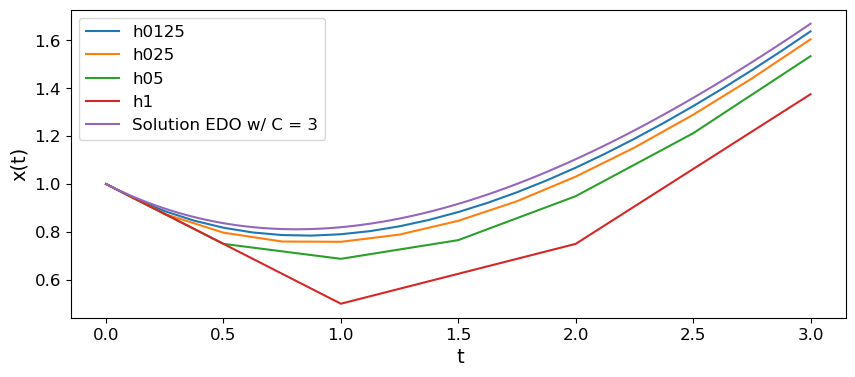

In [76]:
# Plot Euler method results & provided EDO solution with C = 3
fig, ax = plt.subplots(figsize=(10, 4))

for h in h_steps:
    ax.plot(dict_t[h], dict_x[h], label = h)

ax.plot(t_array, x_sol, label = 'Solution EDO w/ C = 3')

ax.set_ylabel(r'x(t)', fontsize = 14)
ax.tick_params(axis='y', labelsize=12) 
ax.set_xlabel(r' t', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.legend(fontsize=12)

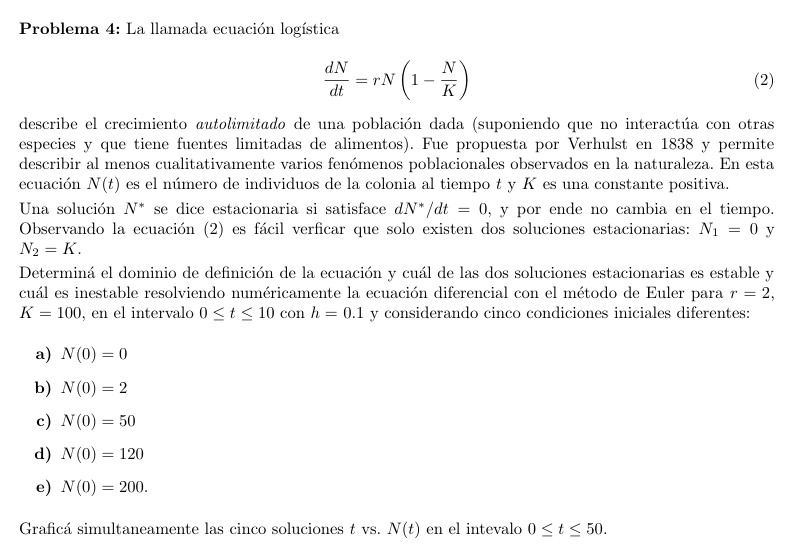

In [77]:
# Import data
paths_list = []
data_path = 'tp3e4'

## Sort directions
path_names = sorted(next(os.walk(data_path))[-1])

# Print paths list
path_names

['output_n0.csv',
 'output_n120.csv',
 'output_n2.csv',
 'output_n200.csv',
 'output_n50.csv']

In [78]:
# Create dicts to extract data
dict_x = {}
dict_t = {}

# Iterate with a for loop to extract data
for p in path_names:

    #p[7:-4]
    data = pd.read_csv(os.path.join(data_path, p), header = None)
    dict_x[p[7:-4]] = data.loc[:, 1].values
    dict_t[p[7:-4]] = data.loc[:, 0].values

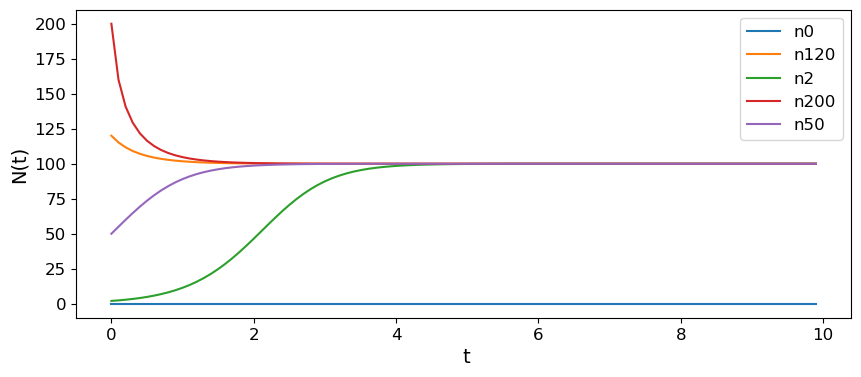

In [ ]:
# Plot Euler method results 0 <= t <= 10
h_steps = dict_x.keys()

fig, ax = plt.subplots(figsize=(10, 4))

for h in h_steps:
    ax.plot(dict_t[h][dict_t[h] <= 10],
             dict_x[h][dict_t[h] <= 10],
               label = h)

ax.set_ylabel(r'N(t)', fontsize = 14)
ax.tick_params(axis='y', labelsize=12) 
ax.set_xlabel(r' t', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.legend(fontsize=12)

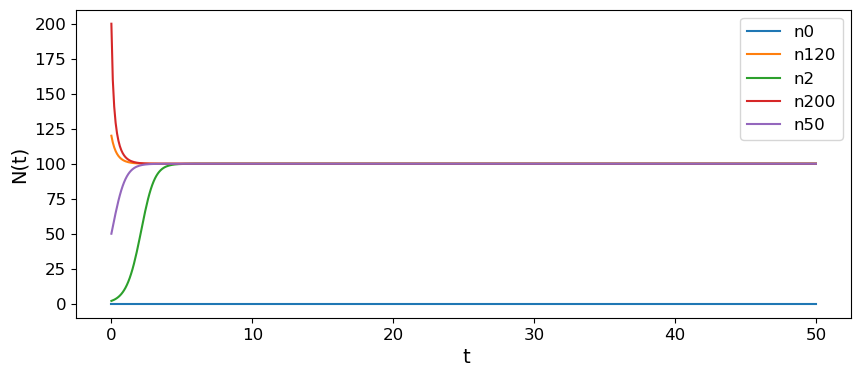

In [ ]:
# Plot Euler method results 0 <= t <= 50
h_steps = dict_x.keys()

fig, ax = plt.subplots(figsize=(10, 4))

for h in h_steps:
    ax.plot(dict_t[h], dict_x[h], label = h)

ax.set_ylabel(r'N(t)', fontsize = 14)
ax.tick_params(axis='y', labelsize=12) 
ax.set_xlabel(r' t', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.legend(fontsize=12)

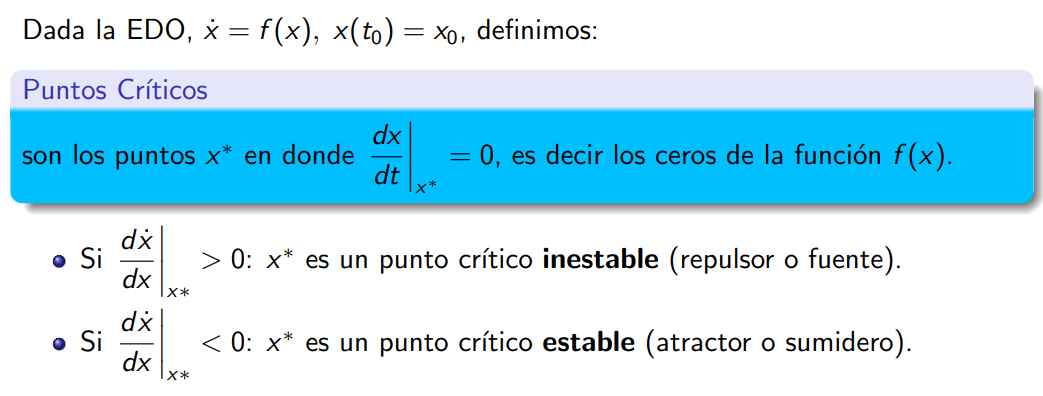

C:\Users\win10\AppData\Local\Temp\ipykernel_18212\976388967.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


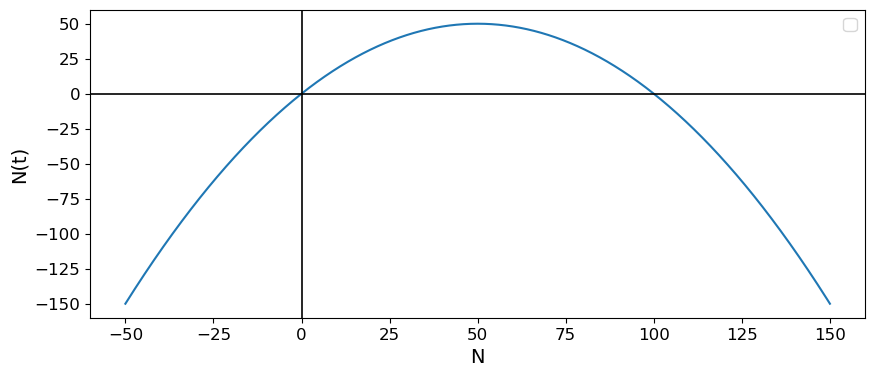

In [ ]:
# Plot dN/dt vs N

N_array = np.linspace(-50, 150, 10000) ## Define N values

def solv_EDO(N_array, r = 2, K = 100):
    return r*N_array*(1-N_array/K)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(N_array, solv_EDO(N_array))

ax.axhline(0, color='black', linewidth=1.2)
ax.axvline(0, color='black', linewidth=1.2)

ax.set_ylabel(r'dN/dt', fontsize = 14)
ax.tick_params(axis='y', labelsize=12) 
ax.set_xlabel(r'N', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.legend(fontsize=12)

**Solución**

- El dominio de dN/dt es todo x y t, tal que x y t $\epsilon$ $R$
- N = 0 es inestable
- N = 100 es estable

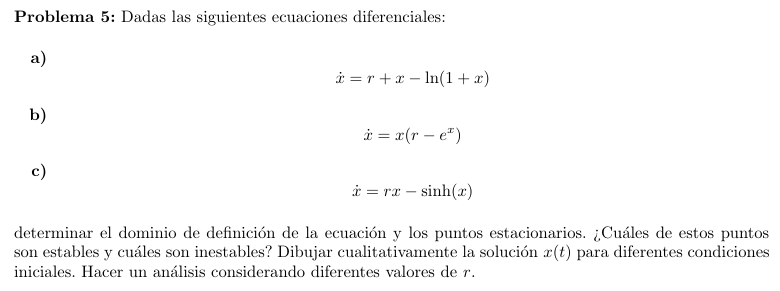

In [67]:
# Define Euler Solver in Python
def euler_solver(f, t0, tf, x0, h):

    # Define steps
    steps = int((tf-t0)/h)

    # Initialize variables
    x = x0
    t = t0

    t_list = [t]
    x_list = [x]

    # For loop
    for i in range(steps-1):

        x = x + h*f(t, x)
        t = t + h

        t_list.append(t)
        x_list.append(x)

    return np.array(t_list), np.array(x_list)

**Ejercicio a**

$\dot{x}$ $= r + x - ln(1+x)$

C:\Users\win10\AppData\Local\Temp\ipykernel_18212\867041930.py:6: RuntimeWarning: invalid value encountered in log
  return r + x_array - np.log(1+x_array)


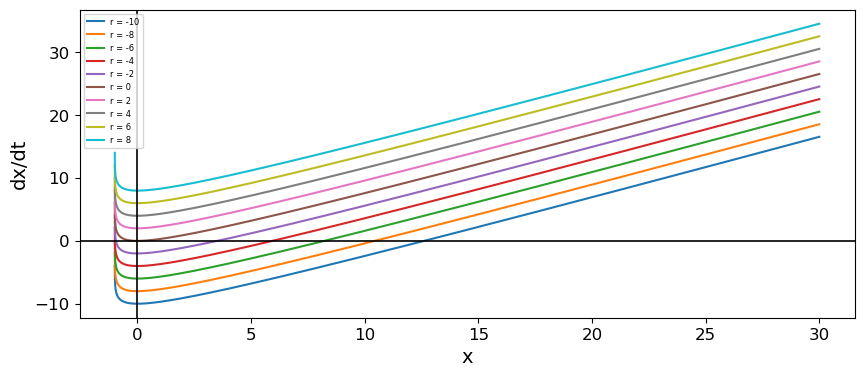

In [53]:
# Plot dx/dt vs x

x_array = np.linspace(-10, 30, 10000) ## Define N values

def f_edo(x_array, r):
    return r + x_array - np.log(1+x_array)

fig, ax = plt.subplots(figsize=(10, 4))

for r in range(-10, 10, 2):

    ax.plot(x_array, f_edo(x_array, r), label=f'r = {r}')

ax.axhline(0, color='black', linewidth=1.2)
ax.axvline(0, color='black', linewidth=1.2)

ax.set_ylabel(r'dx/dt', fontsize = 14)
ax.tick_params(axis='y', labelsize=12) 
ax.set_xlabel(r'x', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.legend(fontsize=6)

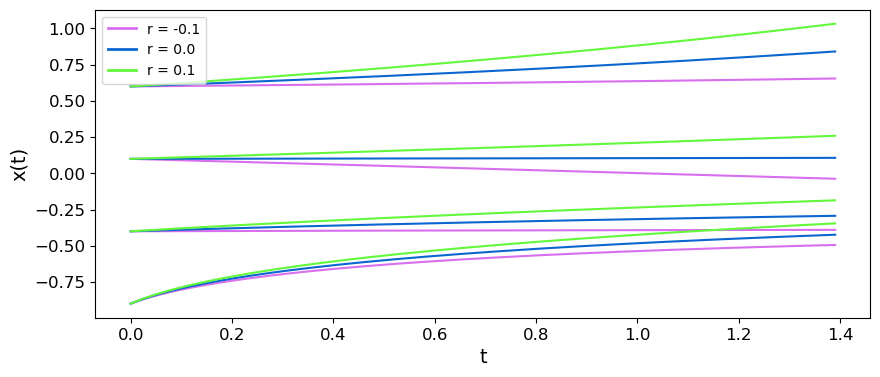

In [110]:
import math
from matplotlib.lines import Line2D

# Define a list of colors
legend_elements = []

#
fig, ax = plt.subplots(figsize=(10, 4))

# Define r and x0 ranges to evaluate
r_range = np.arange(-0.1, 0.11, 0.1)
x0_range = np.arange(-0.9, 1.1, 0.5)

for r in r_range:

    ## Define random colors
    rr = random.randint(1, 255)
    gr = random.randint(1, 255)
    br = random.randint(1, 255)

    ## Add legends manually
    legend_elements.append(Line2D([0], [0], color = (rr/255, gr/255, br/255), lw=2, label= f'r = {r}'))

    ## Foor loop
    for x0 in x0_range:

        # Define f_edo // dx/dt
        def f_edo(t, x):
            #print(r)
            return r + x - math.log(1 + x)

        t, x = euler_solver(f_edo, 0, 1.4, x0, 0.01)

        #print(t, x)
        ax.plot(t, x, label=f'r = {r}', color = (rr/255, gr/255, br/255))

#ax.axhline(0, color='black', linewidth=1.2)
#ax.axvline(0, color='black', linewidth=1.2)

ax.set_ylabel(r'x(t)', fontsize = 14)
ax.tick_params(axis='y', labelsize=12) 
ax.set_xlabel(r't', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.legend(handles=legend_elements, fontsize = 10)


**Ejercicio a**

$\dot{x}$ $= x(r-e^{x})$

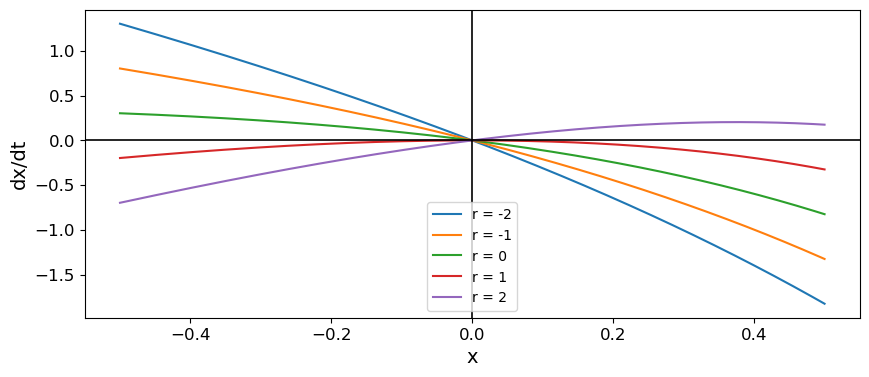

In [109]:
# Plot dx/dt vs x

x_array = np.linspace(-0.5, 0.5, 10000) ## Define N values

def f_edo(x_array, r):
    return x_array*(r-np.exp(x_array))

fig, ax = plt.subplots(figsize=(10, 4))

for r in range(-2, 3, 1):

    ax.plot(x_array, f_edo(x_array, r), label=f'r = {r}')

ax.axhline(0, color='black', linewidth=1.2)
ax.axvline(0, color='black', linewidth=1.2)

ax.set_ylabel(r'dx/dt', fontsize = 14)
ax.tick_params(axis='y', labelsize=12) 
ax.set_xlabel(r'x', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.legend(fontsize=10, loc = 'best')